In [7]:
import numpy as np
import random


def generate_chromosome(bounds):
    return [random.uniform(low, high) for low, high in bounds]

def evaluate(individual, goal_func, args=()):
    return goal_func(np.array(individual), *args)

def roulette_wheel_selection(results):
    fitnesses = [fit for fit, _ in results]
    min_fit = min(fitnesses)
    inverted_fitnesses = [1 / (fit - min_fit + 1e-6) for fit in fitnesses]  # Invert, dodaj epsilon dla uniknięcia div0
    total = sum(inverted_fitnesses)
    pick = random.uniform(0, total)
    current = 0
    for i, inv_fit in enumerate(inverted_fitnesses):
        current += inv_fit
        if current > pick:
            return results[i][1]  # Zwraca individual
    return results[0][1]

def better_crossover(p1, p2, alpha=0.5):
    child = []
    for g1, g2 in zip(p1, p2):
        child.append(alpha * g1 + (1 - alpha) * g2)
    return child

def mutate(child, mutation_rate, bounds, sigma=0.1):
    for i in range(len(child)):
        if random.random() < mutation_rate:
            low, high = bounds[i]
            scale = sigma * (high - low)
            child[i] += random.gauss(0, scale)
            child[i] = max(low, min(high, child[i]))  # Clamp do bounds
    return child

def genetic_algorithm(goal_func, bounds, args=(), generations=100, pop_size=50, mutation_rate=0.1, best_rate=0.2):
    population = [generate_chromosome(bounds) for _ in range(pop_size)]
    best_chromosome = None
    best_fitness = float('inf')
    fitness_history = []

    for gen in range(generations):
        fitnesses = [evaluate(individual, goal_func, args) for individual in population]
        results = list(zip(fitnesses, population))
        results.sort(key=lambda x: x[0])

        if results[0][0] < best_fitness:
            best_fitness = results[0][0]
            best_chromosome = results[0][1][:]  # Kopia listy
        fitness_history.append(best_fitness)

        num_best = int(pop_size * best_rate)
        best_individuals = [ind[:] for fit, ind in results[:num_best]]  # Kopiuj osobniki

        new_population = best_individuals[:]

        while len(new_population) < pop_size:
            p1 = roulette_wheel_selection(results)
            p2 = roulette_wheel_selection(results)
            child = better_crossover(p1, p2)
            child = mutate(child, mutation_rate, bounds)
            new_population.append(child)

        if (gen + 1) % 10 == 0 or gen == 0:
            print(f"Generacja {gen + 1}/{generations}: najlepszy wynik = {best_fitness:.6f}")
        
        population = new_population

    print(f"\nOptymalizacja GA zakończona!")
    print(f"Najlepszy wynik: {best_fitness:.6f}")
    
    return type('Result', (), {'x': np.array(best_chromosome), 'fun': best_fitness, 'nfev': generations * pop_size, 'nit': generations}), fitness_history

In [8]:
# -*- coding: utf-8 -*-
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *

def productN(args, op):
    return np.prod(args, axis=0)
    

class ANFIS:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, 
              n_iter=100, bounds_premises=None, use_genetic_algorithm=False, ga_pop_size=50, ga_mutation_rate=0.1, ga_best_rate=0.2):
        """
        Trenuje model ANFIS używając optymalizacji klasycznej lub algorytmu genetycznego.
        
        Parametry:
        - global_optimization: czy używać optymalizacji globalnej (basinhopping) lub GA
        - learn_premises: czy optymalizować parametry funkcji przynależności
        - learn_operators: czy optymalizować operatory
        - learn_consequents: czy optymalizować parametry TSK
        - n_iter: liczba iteracji (dla klasycznej) lub pokoleń (dla GA)
        - bounds_premises: granice dla parametrów premises (opcjonalne)
        - use_genetic_algorithm: czy użyć algorytmu genetycznego zamiast klasycznej optymalizacji
        - ga_pop_size: wielkość populacji dla GA
        - ga_mutation_rate: prawdopodobieństwo mutacji dla GA
        - ga_best_rate: procent najlepszych osobników (elitaryzm) dla GA
        """
        
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            print("4")
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if use_genetic_algorithm:
                # Algorytm genetyczny
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)
        
        # Zwróć historię fitness jeśli używano GA
        if use_genetic_algorithm:
            return fitness_history
        else:
            return None
    
    def train_with_ga(self, learn_premises: bool, learn_operators: bool, learn_consequents: bool, 
                      generations=100, pop_size=50, mutation_rate=0.1, best_rate=0.2, bounds_premises=None):
        """
        Trenuje ANFIS używając algorytmu genetycznego.
        
        Parametry:
        - learn_premises: czy optymalizować parametry funkcji przynależności
        - learn_operators: czy optymalizować operatory
        - learn_consequents: czy optymalizować parametry TSK
        - generations: liczba pokoleń GA
        - pop_size: wielkość populacji
        - mutation_rate: prawdopodobieństwo mutacji
        - best_rate: procent najlepszych osobników do zachowania
        - bounds_premises: granice dla parametrów premises (opcjonalne)
        """
        
        # Przygotowanie parametrów początkowych
        x1 = [item for sublist in self.premises for item in sublist]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
        
        # Ustalenie granic dla parametrów
        if bounds_premises is None:
            bfv = [(0, 4)] * len(x1)
        else:
            bfv = bounds_premises
        bop = [(0.0, 2.0)] * len(x2)
        btsk = [(0, 2)] * len(x3)
        
        # Wybór odpowiedniej funkcji celu i parametrów
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1, x2, x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1) + len(x2)
            bounds = bfv + bop + btsk
            goal_func = goal_premises_operators_consequents
            print("Optymalizacja GA: premises + operators + consequents")
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1, x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1) + len(x2)
            bounds = bfv + bop
            goal_func = goal_premises_operators
            print("Optymalizacja GA: premises + operators")
            
        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1, x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            bounds = bfv + btsk
            goal_func = goal_premises_consequents
            print("Optymalizacja GA: premises + consequents")
            
        elif learn_operators and learn_consequents:
            x0 = np.hstack((x2, x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            bounds = bop + btsk
            goal_func = goal_operators_consequents
            print("Optymalizacja GA: operators + consequents")
            
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            bounds = bfv
            goal_func = goal_premises
            print("Optymalizacja GA: premises")
            
        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            bounds = bop
            goal_func = goal_operators
            print("Optymalizacja GA: operators")
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            bounds = btsk
            goal_func = goal_consequents
            print("Optymalizacja GA: consequents")
            
        else:
            print("Error: Należy wybrać co najmniej jeden typ parametrów do optymalizacji")
            assert(0)
        
        # Uruchomienie algorytmu genetycznego
        res, fitness_history = genetic_algorithm(
            goal_func=goal_func,
            bounds=bounds,
            args=(self,),
            generations=generations,
            pop_size=pop_size,
            mutation_rate=mutation_rate,
            best_rate=best_rate
        )
        
        # Aktualizacja parametrów modelu najlepszym rozwiązaniem
        if learn_premises and learn_operators and learn_consequents:
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op = res.x[self.end_x1:self.end_x2]
            self.tsk = res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op = res.x[self.end_x1:self.end_x2]
            
        elif learn_premises and learn_consequents:
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.tsk = res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_operators and learn_consequents:
            self.op = res.x[self.end_x1:self.end_x2]
            self.tsk = res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises:
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))
            
        elif learn_operators:
            self.op = res.x[:]
            
        elif learn_consequents:
            self.tsk = res.x[:].reshape(np.shape(self.tsk))
        
        print(f"z błędem:  {res.fun}")
        print(f"Liczba ew: {res.nfev}")
        print(f"Liczba it: {res.nit}")
        
        return fitness_history


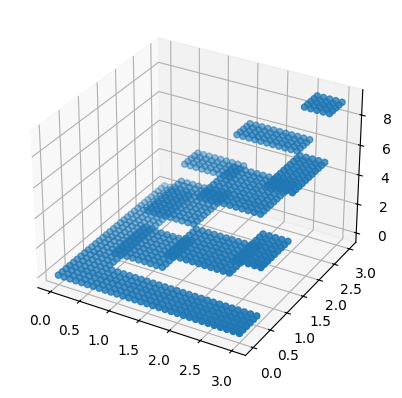

[[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375], [0.375, 0.4375, 0.5625, 0.625]]
['VL', 'L', 'M']
Parametry przed uczeniem:
[[[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375], [0.375, 0.4375, 0.5625, 0.625]], [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375], [0.375, 0.4375, 0.5625, 0.625]]]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[[0.76721849 0.28345184 0.7347964 ]
 [0.58975407 0.43024222 0.86227573]
 [0.47849505 0.78999785 0.13655406]
 [0.91425922 0.06634149 0.50528033]
 [0.48869493 0.56185049 0.33434204]
 [0.50923104 0.92981219 0.88950759]
 [0.11438936 0.72642885 0.47891581]
 [0.28007703 0.45773607 0.70697544]
 [0.37878076 0.40034934 0.01024682]]


C:\Users\jasin\AppData\Local\Temp\ipykernel_6204\835383510.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   54.61448500575228
Liczba ew:  363944
Liczba it:  100
Parametry po uczeniu:
[[[2.1389693  3.11340242 0.08060487 4.        ]
  [0.79715175 1.22500561 2.57386855 0.091602  ]
  [2.51461779 0.02923228 1.2598358  0.06564701]]

 [[2.09986014 3.07107457 0.05416297 0.46737559]
  [0.65810457 1.48504763 3.15172204 0.09890734]
  [3.0052006  0.81519934 0.0950121  1.2810754 ]]]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[[1.28544811e+00 2.34410707e-01 2.00000000e+00]
 [1.06531527e-11 9.59923133e-10 5.14778696e-10]
 [1.51290030e-01 5.90711017e-11 2.00000000e+00]
 [9.17899770e-10 1.06950112e-01 4.09908757e-10]
 [2.77975212e-10 2.03790610e-10 4.95376078e-10]
 [7.97264980e-11 2.98057251e-02 4.33153833e-11]
 [1.96157509e+00 1.45811906e+00 2.00000000e+00]
 [4.26242745e-11 3.02653167e-10 1.41850786e-10]
 [1.75673521e+00 5.29926739e-11 5.42631616e-01]]
ZBIÓR TRENINGOWY:


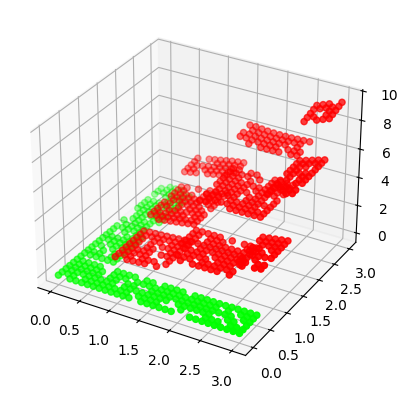

ZBIÓR TESTOWY:


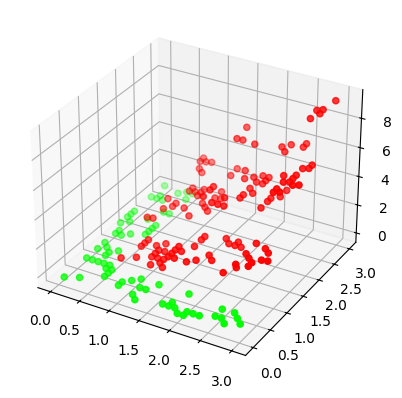

Czas uczenia: 94.51 s
MSE na zbiorze testowym: 0.0126
Macierz pomyłek:
[[68  0  0  0  0  0  0]
 [ 0 16  0  0  0  0  0]
 [ 0  0 40  0  0  0  0]
 [ 0  0  0 18  0  0  0]
 [ 0  0  0  0 24  0  0]
 [ 0  0  0  0  0 22  0]
 [ 0  0  0  0  0  0  5]]




In [9]:
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
            [0.375, 0.4375, 0.5625, 0.625], [0.625, 0.6875, 0.8125, 0.875], 
            [0.75, 0.875, 1, 1]]

labels_list = ["VL","L", "M", "H", "VH"]

x = np.arange(0, 3 + 0.1, 0.1)
y = np.arange(0, 3 + 0.1, 0.1)
xx, yy = np.meshgrid(x, y)
    
dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX) * np.round(dataY)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dataX, dataY, data_labels)
plt.show()

membership = mf_list[:3]
print(membership)
labels = labels_list[:3]
print(labels)
varX = FuzzyInputVariable_List_Trapezoids(membership, "XAxis", labels)
varY = FuzzyInputVariable_List_Trapezoids(membership, "YAxis", labels)

X_train, X_test, y_train, y_test = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)
    
fis = ANFIS([varX, varY], X_train.T, y_train, operator_init_value=0.5)    

print(f"Parametry przed uczeniem:")
print(fis.premises)
print(fis.op)
print(fis.tsk)

start = time.time()
fis.train(
        global_optimization=True, 
        learn_premises=True, 
        learn_operators=False, 
        learn_consequents=True, 
        n_iter=100
)

print(f"Parametry po uczeniu:")
print(fis.premises)
print(fis.op)
print(fis.tsk)

end = time.time()
elapsed = end - start
print("ZBIÓR TRENINGOWY:")
fis.show_results()

fis.training_data = X_test.T
fis.expected_labels = y_test
print("ZBIÓR TESTOWY:")
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
mse = np.mean((y_test - y_pred.flatten())**2)
    
print(f"Czas uczenia: {elapsed:.2f} s")
print(f"MSE na zbiorze testowym: {mse:.4f}")
print("Macierz pomyłek:")
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))
print("\n")


# Algorytm Genetyczny dla optymalizacji ANFIS

## Opis implementacji

Algorytm genetyczny został zaprojektowany do optymalizacji parametrów modelu ANFIS:

### Genotyp (chromosom)
Genotyp składa się z parametrów ANFIS połączonych w jeden wektor:
- **premises** - parametry funkcji przynależności (a, b, c, d dla każdej funkcji trapezoidalnej)
- **op** - parametry operatorów (wartości dla każdego węzła reguł)
- **tsk** - parametry konsekwentów TSK (współczynniki dla każdej reguły)

### Parametry algorytmu
- `generations` - liczba pokoleń (iteracji)
- `pop_size` - wielkość populacji
- `mutation_rate` - prawdopodobieństwo mutacji (0.0 - 1.0)
- `best_rate` - procent najlepszych osobników zachowywanych w każdym pokoleniu (elitaryzm)

### Mechanizmy genetyczne

1. **Selekcja**: Ruletkowa z inwersją fitness (minimalizujemy błąd)
2. **Krzyżowanie**: Arytmetyczne (średnia ważona rodziców)
3. **Mutacja**: Gaussowska z ograniczeniem do granic
4. **Elitaryzm**: Najlepsze osobniki przechodzą bez zmian do następnej generacji

### Funkcja celu
Wykorzystuje funkcje celu z ANFIS (`goal_premises_operators_consequents`, etc.) które obliczają błąd MSE między przewidywaniami a rzeczywistymi wartościami.

## Jak używać

### Podstawowe użycie:

```python
# Stworzenie modelu ANFIS
fis = ANFIS([varX, varY], training_data, expected_labels)

# Trenowanie z algorytmem genetycznym
fitness_history = fis.train_with_ga(
    learn_premises=True,      # Optymalizuj funkcje przynależności
    learn_operators=False,    # Nie optymalizuj operatorów
    learn_consequents=True,   # Optymalizuj parametry TSK
    generations=100,          # Liczba pokoleń
    pop_size=50,              # Wielkość populacji
    mutation_rate=0.15,       # Prawdopodobieństwo mutacji
    best_rate=0.2             # Procent elity (20%)
)
```

### Parametry metody `train_with_ga`:

- **learn_premises** (bool): Czy optymalizować parametry funkcji przynależności
- **learn_operators** (bool): Czy optymalizować operatory t-normy
- **learn_consequents** (bool): Czy optymalizować parametry konsekwentów TSK
- **generations** (int): Liczba pokoleń algorytmu genetycznego
- **pop_size** (int): Wielkość populacji
- **mutation_rate** (float): Prawdopodobieństwo mutacji pojedynczego genu (0.0-1.0)
- **best_rate** (float): Procent najlepszych osobników zachowywanych w każdej generacji (0.0-1.0)
- **bounds_premises** (list): Opcjonalne granice dla parametrów premises

### Zwracana wartość:

- **fitness_history** (list): Historia najlepszego fitness w każdym pokoleniu (użyteczne do wizualizacji)

# Przykład użycia algorytmu genetycznego do optymalizacji ANFIS

Ten przykład pokazuje jak używać algorytmu genetycznego do optymalizacji parametrów ANFIS.

PRZYKŁAD 1: Optymalizacja ANFIS za pomocą algorytmu genetycznego

Parametry przed uczeniem GA:
Premises shape: (2, 3, 4)
Operators length: 9
TSK shape: (9, 3)
Optymalizacja GA: premises + consequents
Generacja 1/1000: najlepszy wynik = 1005.557810
Generacja 10/1000: najlepszy wynik = 661.964999
Generacja 20/1000: najlepszy wynik = 488.040798


C:\Users\jasin\AppData\Local\Temp\ipykernel_6204\835383510.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Generacja 30/1000: najlepszy wynik = 411.861308
Generacja 40/1000: najlepszy wynik = 341.020495
Generacja 50/1000: najlepszy wynik = 333.203665
Generacja 60/1000: najlepszy wynik = 321.041842
Generacja 70/1000: najlepszy wynik = 315.366516
Generacja 80/1000: najlepszy wynik = 311.519719
Generacja 90/1000: najlepszy wynik = 309.291895
Generacja 100/1000: najlepszy wynik = 307.406578
Generacja 110/1000: najlepszy wynik = 305.590899
Generacja 120/1000: najlepszy wynik = 304.616256
Generacja 130/1000: najlepszy wynik = 303.483676
Generacja 140/1000: najlepszy wynik = 299.155654
Generacja 150/1000: najlepszy wynik = 297.155383
Generacja 160/1000: najlepszy wynik = 295.661242
Generacja 170/1000: najlepszy wynik = 293.948870
Generacja 180/1000: najlepszy wynik = 293.179252
Generacja 190/1000: najlepszy wynik = 287.499925
Generacja 200/1000: najlepszy wynik = 284.798902
Generacja 210/1000: najlepszy wynik = 283.623983
Generacja 220/1000: najlepszy wynik = 282.420095
Generacja 230/1000: najleps

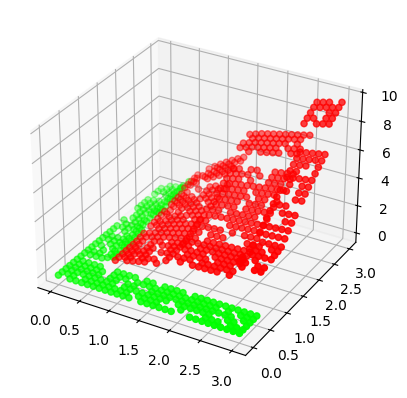

ZBIÓR TESTOWY (GA):


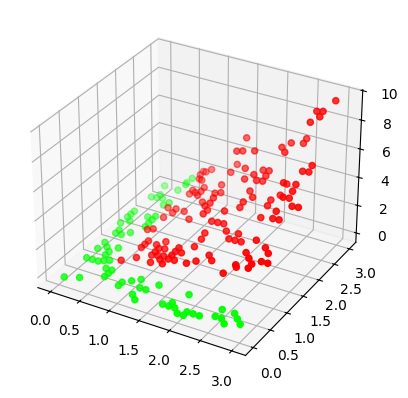


Czas uczenia GA: 8.10 s
MSE na zbiorze testowym: 0.2660
Macierz pomyłek:
[[59  9  0  0  0  0  0  0  0  0]
 [ 0 16  0  0  0  0  0  0  0  0]
 [ 0  6 30  4  0  0  0  0  0  0]
 [ 0  0  6 11  1  0  0  0  0  0]
 [ 0  0  0  9 12  3  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  3 10  8  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  4]]


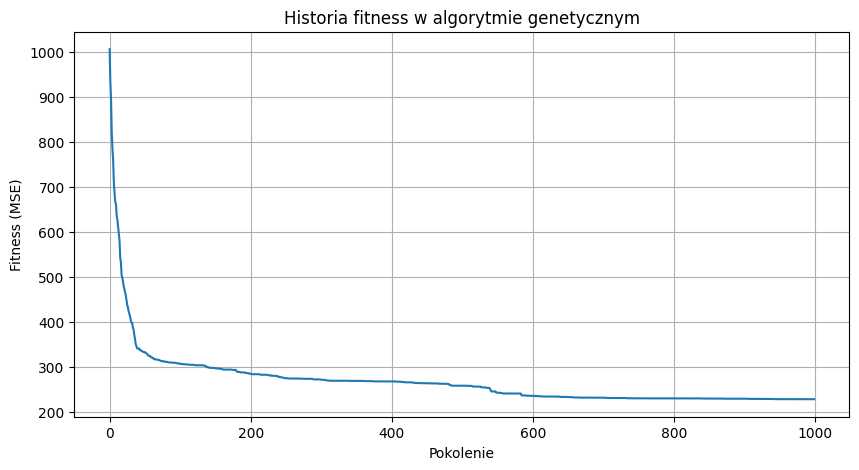

In [12]:
# Przykład 1: Optymalizacja wszystkich parametrów za pomocą GA
print("=" * 80)
print("PRZYKŁAD 1: Optymalizacja ANFIS za pomocą algorytmu genetycznego")
print("=" * 80)

# Tworzenie nowego modelu ANFIS
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
            [0.375, 0.4375, 0.5625, 0.625], [0.625, 0.6875, 0.8125, 0.875], 
            [0.75, 0.875, 1, 1]]

labels_list = ["VL","L", "M", "H", "VH"]

x = np.arange(0, 3 + 0.1, 0.1)
y = np.arange(0, 3 + 0.1, 0.1)
xx, yy = np.meshgrid(x, y)
    
dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX) * np.round(dataY)

membership = mf_list[:3]
labels = labels_list[:3]
varX = FuzzyInputVariable_List_Trapezoids(membership, "XAxis", labels)
varY = FuzzyInputVariable_List_Trapezoids(membership, "YAxis", labels)

X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)
    
fis_ga = ANFIS([varX, varY], X_train_ga.T, y_train_ga, operator_init_value=0.5)    

print(f"\nParametry przed uczeniem GA:")
print(f"Premises shape: {np.shape(fis_ga.premises)}")
print(f"Operators length: {len(fis_ga.op)}")
print(f"TSK shape: {np.shape(fis_ga.tsk)}")

start = time.time()

# Trenowanie za pomocą algorytmu genetycznego
fitness_history = fis_ga.train_with_ga(
    learn_premises=True, 
    learn_operators=False, 
    learn_consequents=True, 
    generations=1000,      # Mniejsza liczba pokoleń dla szybszego testu
    pop_size=30,         # Mniejsza populacja
    mutation_rate=0.15,
    best_rate=0.2
)

end = time.time()
elapsed = end - start

print(f"\nParametry po uczeniu GA:")
print(f"Premises:\n{fis_ga.premises}")
print(f"Operators: {fis_ga.op}")
print(f"TSK:\n{fis_ga.tsk}")

# Wyniki na zbiorze treningowym
print("\n" + "=" * 80)
print("ZBIÓR TRENINGOWY (GA):")
fis_ga.show_results()

# Wyniki na zbiorze testowym
fis_ga.training_data = X_test_ga.T
fis_ga.expected_labels = y_test_ga
print("ZBIÓR TESTOWY (GA):")
fis_ga.show_results()

y_pred_ga = fis_ga.anfis_estimate_labels(fis_ga.premises, fis_ga.op, fis_ga.tsk)
mse_ga = np.mean((y_test_ga - y_pred_ga.flatten())**2)
    
print(f"\nCzas uczenia GA: {elapsed:.2f} s")
print(f"MSE na zbiorze testowym: {mse_ga:.4f}")
print("Macierz pomyłek:")
y_pred_ga_rounded = list(map(round, y_pred_ga.flatten()))
print(confusion_matrix(y_test_ga, y_pred_ga_rounded))

# Wykres historii fitness
plt.figure(figsize=(10, 5))
plt.plot(fitness_history)
plt.xlabel('Pokolenie')
plt.ylabel('Fitness (MSE)')
plt.title('Historia fitness w algorytmie genetycznym')
plt.grid(True)
plt.show()

# Porównanie algorytmu genetycznego z optymalizacją klasyczną

Poniżej przykład porównujący wydajność algorytmu genetycznego z metodą basinhopping.

In [6]:
# Przykład 2: Porównanie GA z optymalizacją klasyczną
print("=" * 80)
print("PRZYKŁAD 2: Porównanie GA vs Klasyczna optymalizacja")
print("=" * 80)

# Przygotowanie danych
membership_comp = mf_list[:3]
labels_comp = labels_list[:3]
varX_comp = FuzzyInputVariable_List_Trapezoids(membership_comp, "XAxis", labels_comp)
varY_comp = FuzzyInputVariable_List_Trapezoids(membership_comp, "YAxis", labels_comp)

X_train_comp, X_test_comp, y_train_comp, y_test_comp = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

# Model 1: Algorytm genetyczny
print("\n--- Trenowanie z algorytmem genetycznym ---")
fis_ga_comp = ANFIS([varX_comp, varY_comp], X_train_comp.T, y_train_comp, operator_init_value=0.5)
start_ga = time.time()
history_ga = fis_ga_comp.train_with_ga(
    learn_premises=True, 
    learn_operators=False, 
    learn_consequents=True, 
    generations=30,
    pop_size=20,
    mutation_rate=0.15,
    best_rate=0.2
)
time_ga = time.time() - start_ga

# Ewaluacja GA
fis_ga_comp.training_data = X_test_comp.T
fis_ga_comp.expected_labels = y_test_comp
y_pred_ga_comp = fis_ga_comp.anfis_estimate_labels(fis_ga_comp.premises, fis_ga_comp.op, fis_ga_comp.tsk)
mse_ga_comp = np.mean((y_test_comp - y_pred_ga_comp.flatten())**2)

# Model 2: Klasyczna optymalizacja (basinhopping)
print("\n--- Trenowanie z klasyczną optymalizacją ---")
fis_classic = ANFIS([varX_comp, varY_comp], X_train_comp.T, y_train_comp, operator_init_value=0.5)
start_classic = time.time()
fis_classic.train(
    global_optimization=True, 
    learn_premises=True, 
    learn_operators=False, 
    learn_consequents=True, 
    n_iter=30
)
time_classic = time.time() - start_classic

# Ewaluacja klasycznej
fis_classic.training_data = X_test_comp.T
fis_classic.expected_labels = y_test_comp
y_pred_classic = fis_classic.anfis_estimate_labels(fis_classic.premises, fis_classic.op, fis_classic.tsk)
mse_classic = np.mean((y_test_comp - y_pred_classic.flatten())**2)

# Porównanie wyników
print("\n" + "=" * 80)
print("PORÓWNANIE WYNIKÓW:")
print("=" * 80)
print(f"\nAlgorytm genetyczny:")
print(f"  - Czas: {time_ga:.2f} s")
print(f"  - MSE:  {mse_ga_comp:.6f}")

print(f"\nKlasyczna optymalizacja:")
print(f"  - Czas: {time_classic:.2f} s")
print(f"  - MSE:  {mse_classic:.6f}")

print(f"\nRóżnica MSE: {abs(mse_ga_comp - mse_classic):.6f}")
print(f"Lepszy wynik: {'GA' if mse_ga_comp < mse_classic else 'Klasyczna optymalizacja'}")

# Wykres porównawczy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Historia GA
ax1.plot(history_ga)
ax1.set_xlabel('Pokolenie')
ax1.set_ylabel('Fitness (MSE)')
ax1.set_title('Algorytm genetyczny - Historia fitness')
ax1.grid(True)

# Porównanie MSE
methods = ['GA', 'Klasyczna']
mses = [mse_ga_comp, mse_classic]
colors = ['blue', 'red']
ax2.bar(methods, mses, color=colors, alpha=0.7)
ax2.set_ylabel('MSE')
ax2.set_title('Porównanie błędu MSE')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

PRZYKŁAD 2: Porównanie GA vs Klasyczna optymalizacja

--- Trenowanie z algorytmem genetycznym ---
Optymalizacja GA: premises + consequents
Generacja 1/30: najlepszy wynik = 1045.078562
Generacja 10/30: najlepszy wynik = 583.526697
Generacja 20/30: najlepszy wynik = 452.409311
Generacja 30/30: najlepszy wynik = 430.471283

Optymalizacja GA zakończona!
Najlepszy wynik: 430.471283
z błędem:  430.47128292840927
Liczba ew: 600
Liczba it: 30

--- Trenowanie z klasyczną optymalizacją ---


C:\Users\jasin\AppData\Local\Temp\ipykernel_6204\3072512871.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


KeyboardInterrupt: 

# Optymalizacja różnych kombinacji parametrów

Możesz optymalizować różne kombinacje parametrów ANFIS:

In [ ]:
# Przykład 3: Optymalizacja różnych kombinacji parametrów
print("=" * 80)
print("PRZYKŁAD 3: Różne kombinacje parametrów do optymalizacji")
print("=" * 80)

# Przygotowanie wspólnych danych
membership_comb = mf_list[:3]
labels_comb = labels_list[:3]
varX_comb = FuzzyInputVariable_List_Trapezoids(membership_comb, "XAxis", labels_comb)
varY_comb = FuzzyInputVariable_List_Trapezoids(membership_comb, "YAxis", labels_comb)

X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

# Testowanie różnych kombinacji
configs = [
    {"name": "Tylko premises", "learn_premises": True, "learn_operators": False, "learn_consequents": False},
    {"name": "Tylko consequents", "learn_premises": False, "learn_operators": False, "learn_consequents": True},
    {"name": "Premises + Consequents", "learn_premises": True, "learn_operators": False, "learn_consequents": True},
    {"name": "Wszystkie parametry", "learn_premises": True, "learn_operators": True, "learn_consequents": True},
]

results = []

for config in configs:
    print(f"\n--- {config['name']} ---")
    
    # Tworzenie nowego modelu dla każdej konfiguracji
    fis_config = ANFIS([varX_comb, varY_comb], X_train_comb.T, y_train_comb, operator_init_value=0.5)
    
    start_time = time.time()
    
    # Trenowanie z GA
    history = fis_config.train_with_ga(
        learn_premises=config['learn_premises'],
        learn_operators=config['learn_operators'],
        learn_consequents=config['learn_consequents'],
        generations=20,  # Krótsze dla szybkiego testu
        pop_size=20,
        mutation_rate=0.15,
        best_rate=0.2
    )
    
    elapsed_time = time.time() - start_time
    
    # Ewaluacja
    fis_config.training_data = X_test_comb.T
    fis_config.expected_labels = y_test_comb
    y_pred_config = fis_config.anfis_estimate_labels(fis_config.premises, fis_config.op, fis_config.tsk)
    mse_config = np.mean((y_test_comb - y_pred_config.flatten())**2)
    
    results.append({
        'name': config['name'],
        'mse': mse_config,
        'time': elapsed_time,
        'final_fitness': history[-1]
    })
    
    print(f"MSE: {mse_config:.6f}, Czas: {elapsed_time:.2f}s")

# Podsumowanie wyników
print("\n" + "=" * 80)
print("PODSUMOWANIE:")
print("=" * 80)
for r in results:
    print(f"{r['name']:30s} - MSE: {r['mse']:.6f}, Czas: {r['time']:.2f}s")

# Wykres wyników
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

names = [r['name'] for r in results]
mses = [r['mse'] for r in results]
times = [r['time'] for r in results]

# MSE
ax1.barh(names, mses, color='steelblue', alpha=0.7)
ax1.set_xlabel('MSE')
ax1.set_title('Błąd MSE dla różnych konfiguracji')
ax1.grid(True, axis='x')

# Czas
ax2.barh(names, times, color='coral', alpha=0.7)
ax2.set_xlabel('Czas [s]')
ax2.set_title('Czas trenowania dla różnych konfiguracji')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"\nNajlepsza konfiguracja (MSE): {min(results, key=lambda x: x['mse'])['name']}")
print(f"Najszybsza konfiguracja: {min(results, key=lambda x: x['time'])['name']}")

# Wskazówki i najlepsze praktyki

## Dobór parametrów GA:

1. **Wielkość populacji (`pop_size`)**:
   - Mniejsza populacja (20-30): szybsze, ale może utknąć w lokalnym minimum
   - Większa populacja (50-100): wolniejsze, ale lepsze eksplorowanie przestrzeni

2. **Liczba pokoleń (`generations`)**:
   - Dla prostych problemów: 20-50
   - Dla złożonych problemów: 100-200
   - Obserwuj wykres fitness - jeśli przestaje się poprawiać, możesz zatrzymać wcześniej

3. **Współczynnik mutacji (`mutation_rate`)**:
   - Niski (0.05-0.10): bardziej zachowawcze, powolna eksploracja
   - Średni (0.10-0.20): dobry balans
   - Wysoki (0.20-0.30): agresywna eksploracja, może destabilizować dobre rozwiązania

4. **Współczynnik elity (`best_rate`)**:
   - 0.10-0.20 (10-20%): standardowe wartości
   - Wyższe wartości przyspieszają zbieżność, ale mogą ograniczać różnorodność

## Porównanie z klasyczną optymalizacją:

| Metoda | Zalety | Wady |
|--------|--------|------|
| **GA** | - Lepsza eksploracja przestrzeni<br>- Mniej prawdopodobne utknięcie w lokalnym minimum<br>- Równoległa eksploracja wielu rozwiązań | - Wolniejsza<br>- Wymaga więcej wywołań funkcji celu<br>- Wyniki mogą się różnić między uruchomieniami |
| **Klasyczna (gradient-based)** | - Szybsza zbieżność<br>- Deterministyczna<br>- Mniej wywołań funkcji celu | - Może utknąć w lokalnym minimum<br>- Zależna od punktu startowego<br>- Wymaga gradientów |

## Kiedy używać GA:

- Gdy klasyczna optymalizacja utyka w lokalnym minimum
- Gdy przestrzeń poszukiwań ma wiele minimów lokalnych
- Gdy chcesz zbadać różne regiony przestrzeni parametrów
- Gdy masz dużo czasu na trenowanie (GA jest wolniejsze)

# Szybki start

## Prosty przykład krok po kroku:

```python
# 1. Import i przygotowanie danych
from params import FuzzyInputVariable_List_Trapezoids
from sklearn.model_selection import train_test_split
import numpy as np

# 2. Definicja funkcji przynależności
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
           [0.375, 0.4375, 0.5625, 0.625]]
labels = ["L", "M", "H"]

varX = FuzzyInputVariable_List_Trapezoids(mf_list, "X", labels)
varY = FuzzyInputVariable_List_Trapezoids(mf_list, "Y", labels)

# 3. Przygotowanie danych treningowych
# ... (Twoje dane: X_train, y_train)

# 4. Utworzenie modelu ANFIS
fis = ANFIS([varX, varY], X_train.T, y_train)

# 5. Trenowanie z GA
fitness_history = fis.train_with_ga(
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    generations=50,
    pop_size=30
)

# 6. Przewidywanie
y_pred = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)

# 7. Ewaluacja
mse = np.mean((y_test - y_pred.flatten())**2)
print(f"MSE: {mse}")
```

---
**Autor:** Implementacja GA dla ANFIS  
**Data:** 2025  
**Wersja:** 1.0

# Zintegrowany algorytm genetyczny w metodzie train()

Algorytm genetyczny został zintegrowany bezpośrednio w oryginalnej metodzie `train()` klasy ANFIS. Teraz możesz używać GA poprzez ustawienie parametru `use_genetic_algorithm=True`.

## Dokumentacja metody train() z GA

### Sygnatura metody:

```python
def train(self, 
          global_optimization: bool, 
          learn_premises: bool, 
          learn_operators: bool, 
          learn_consequents: bool, 
          n_iter=100, 
          bounds_premises=None, 
          use_genetic_algorithm=False,  # NOWY PARAMETR
          ga_pop_size=50,                # NOWY PARAMETR
          ga_mutation_rate=0.1,          # NOWY PARAMETR
          ga_best_rate=0.2)              # NOWY PARAMETR
```

### Parametry:

- **global_optimization** (bool): Czy używać optymalizacji globalnej
  - `False` → Lokalna optymalizacja (minimize)
  - `True` + `use_genetic_algorithm=False` → Globalna optymalizacja (basinhopping)
  - `True` + `use_genetic_algorithm=True` → Algorytm genetyczny

- **learn_premises** (bool): Optymalizuj funkcje przynależności
- **learn_operators** (bool): Optymalizuj operatory t-normy
- **learn_consequents** (bool): Optymalizuj parametry TSK
- **n_iter** (int): Liczba iteracji (basinhopping) lub pokoleń (GA)
- **bounds_premises** (list): Opcjonalne granice dla premises

**Nowe parametry dla GA:**
- **use_genetic_algorithm** (bool): Czy użyć GA zamiast klasycznej optymalizacji
- **ga_pop_size** (int): Wielkość populacji GA (domyślnie: 50)
- **ga_mutation_rate** (float): Prawdopodobieństwo mutacji (domyślnie: 0.1)
- **ga_best_rate** (float): Procent elity (domyślnie: 0.2)

### Zwracana wartość:

- **fitness_history** (list | None): Historia fitness dla GA, lub None dla klasycznej optymalizacji

### Przykłady użycia:

```python
# 1. Optymalizacja lokalna
fis.train(global_optimization=False, 
          learn_premises=True, 
          learn_consequents=True)

# 2. Optymalizacja globalna (basinhopping)
fis.train(global_optimization=True, 
          learn_premises=True, 
          learn_consequents=True,
          use_genetic_algorithm=False)

# 3. Algorytm genetyczny
history = fis.train(global_optimization=True, 
                    learn_premises=True, 
                    learn_consequents=True,
                    use_genetic_algorithm=True,
                    ga_pop_size=30,
                    ga_mutation_rate=0.15,
                    n_iter=50)  # 50 pokoleń
```

In [ ]:
# Przykład użycia zintegrowanego GA w metodzie train()
print("=" * 80)
print("PRZYKŁAD: Użycie algorytmu genetycznego przez metodę train()")
print("=" * 80)

# Przygotowanie danych
mf_list_integrated = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
                      [0.375, 0.4375, 0.5625, 0.625]]
labels_integrated = ["L", "M", "H"]

varX_integrated = FuzzyInputVariable_List_Trapezoids(mf_list_integrated, "XAxis", labels_integrated)
varY_integrated = FuzzyInputVariable_List_Trapezoids(mf_list_integrated, "YAxis", labels_integrated)

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

# Tworzenie modelu ANFIS
fis_integrated = ANFIS([varX_integrated, varY_integrated], X_train_int.T, y_train_int, operator_init_value=0.5)

print("\nParametry przed uczeniem:")
print(f"Premises shape: {np.shape(fis_integrated.premises)}")
print(f"Operators length: {len(fis_integrated.op)}")
print(f"TSK shape: {np.shape(fis_integrated.tsk)}")

start = time.time()

# Trenowanie z algorytmem genetycznym poprzez metodę train()
print("\n--- Trenowanie z GA (use_genetic_algorithm=True) ---")
fitness_history_integrated = fis_integrated.train(
    global_optimization=True,    # Musi być True, aby użyć GA lub basinhopping
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,                   # Liczba pokoleń dla GA
    use_genetic_algorithm=True,  # WŁĄCZ ALGORYTM GENETYCZNY
    ga_pop_size=25,             # Wielkość populacji
    ga_mutation_rate=0.15,      # Prawdopodobieństwo mutacji
    ga_best_rate=0.2            # Procent elity
)

elapsed = time.time() - start

print(f"\nParametry po uczeniu:")
print(f"Premises:\n{fis_integrated.premises}")
print(f"TSK:\n{fis_integrated.tsk}")

# Ewaluacja na zbiorze testowym
fis_integrated.training_data = X_test_int.T
fis_integrated.expected_labels = y_test_int
y_pred_int = fis_integrated.anfis_estimate_labels(fis_integrated.premises, fis_integrated.op, fis_integrated.tsk)
mse_int = np.mean((y_test_int - y_pred_int.flatten())**2)

print(f"\nCzas uczenia: {elapsed:.2f} s")
print(f"MSE na zbiorze testowym: {mse_int:.6f}")

# Wizualizacja wyników
print("\nZBIÓR TESTOWY:")
fis_integrated.show_results()

# Wykres historii fitness
if fitness_history_integrated is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history_integrated, linewidth=2)
    plt.xlabel('Pokolenie', fontsize=12)
    plt.ylabel('Fitness (MSE)', fontsize=12)
    plt.title('Historia fitness - Zintegrowany GA w train()', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n" + "=" * 80)
print("PORÓWNANIE: Klasyczna optymalizacja vs GA")
print("=" * 80)

# Dla porównania - klasyczna optymalizacja
fis_classic_comp = ANFIS([varX_integrated, varY_integrated], X_train_int.T, y_train_int, operator_init_value=0.5)

print("\n--- Trenowanie klasyczne (use_genetic_algorithm=False) ---")
start_classic_comp = time.time()
fis_classic_comp.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,
    use_genetic_algorithm=False  # KLASYCZNA OPTYMALIZACJA
)
time_classic_comp = time.time() - start_classic_comp

fis_classic_comp.training_data = X_test_int.T
fis_classic_comp.expected_labels = y_test_int
y_pred_classic_comp = fis_classic_comp.anfis_estimate_labels(fis_classic_comp.premises, fis_classic_comp.op, fis_classic_comp.tsk)
mse_classic_comp = np.mean((y_test_int - y_pred_classic_comp.flatten())**2)

print(f"\n{'Metoda':<25} {'MSE':<15} {'Czas [s]':<10}")
print("-" * 50)
print(f"{'GA (zintegrowany)':<25} {mse_int:<15.6f} {elapsed:<10.2f}")
print(f"{'Klasyczna (basinhopping)':<25} {mse_classic_comp:<15.6f} {time_classic_comp:<10.2f}")
print("-" * 50)
print(f"{'Lepszy wynik:':<25} {'GA' if mse_int < mse_classic_comp else 'Klasyczna'}")
print(f"{'Różnica MSE:':<25} {abs(mse_int - mse_classic_comp):.6f}")

## Prosty przykład - porównanie trzech metod

Poniżej prosty przykład pokazujący różnicę między:
1. Optymalizacją lokalną (minimize)
2. Optymalizacją globalną (basinhopping)
3. Algorytmem genetycznym

In [ ]:
# Przykład porównania trzech metod optymalizacji
print("=" * 80)
print("PORÓWNANIE TRZECH METOD OPTYMALIZACJI W train()")
print("=" * 80)

# Wspólne dane dla wszystkich testów
mf_simple = mf_list[:3]
labels_simple = labels_list[:3]
varX_simple = FuzzyInputVariable_List_Trapezoids(mf_simple, "X", labels_simple)
varY_simple = FuzzyInputVariable_List_Trapezoids(mf_simple, "Y", labels_simple)

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

results_comparison = []

# 1. Optymalizacja lokalna (minimize)
print("\n1. OPTYMALIZACJA LOKALNA (minimize)")
print("-" * 80)
fis1 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start1 = time.time()
fis1.train(
    global_optimization=False,  # Lokalna optymalizacja
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30
)
time1 = time.time() - start1

fis1.training_data = X_test_simple.T
fis1.expected_labels = y_test_simple
y_pred1 = fis1.anfis_estimate_labels(fis1.premises, fis1.op, fis1.tsk)
mse1 = np.mean((y_test_simple - y_pred1.flatten())**2)
results_comparison.append(("Lokalna (minimize)", mse1, time1))

# 2. Optymalizacja globalna (basinhopping)
print("\n2. OPTYMALIZACJA GLOBALNA (basinhopping)")
print("-" * 80)
fis2 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start2 = time.time()
fis2.train(
    global_optimization=True,   # Globalna optymalizacja
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,
    use_genetic_algorithm=False  # Basinhopping
)
time2 = time.time() - start2

fis2.training_data = X_test_simple.T
fis2.expected_labels = y_test_simple
y_pred2 = fis2.anfis_estimate_labels(fis2.premises, fis2.op, fis2.tsk)
mse2 = np.mean((y_test_simple - y_pred2.flatten())**2)
results_comparison.append(("Globalna (basinhopping)", mse2, time2))

# 3. Algorytm genetyczny
print("\n3. ALGORYTM GENETYCZNY")
print("-" * 80)
fis3 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start3 = time.time()
history3 = fis3.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,                   # 30 pokoleń
    use_genetic_algorithm=True,  # ALGORYTM GENETYCZNY
    ga_pop_size=25,
    ga_mutation_rate=0.15,
    ga_best_rate=0.2
)
time3 = time.time() - start3

fis3.training_data = X_test_simple.T
fis3.expected_labels = y_test_simple
y_pred3 = fis3.anfis_estimate_labels(fis3.premises, fis3.op, fis3.tsk)
mse3 = np.mean((y_test_simple - y_pred3.flatten())**2)
results_comparison.append(("Algorytm genetyczny", mse3, time3))

# Podsumowanie
print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW")
print("=" * 80)
print(f"\n{'Metoda':<30} {'MSE':<15} {'Czas [s]':<12} {'Ocena':<15}")
print("-" * 80)

best_mse = min(r[1] for r in results_comparison)
for name, mse, time_val in results_comparison:
    rating = "★ NAJLEPSZY" if mse == best_mse else ""
    print(f"{name:<30} {mse:<15.6f} {time_val:<12.2f} {rating:<15}")

print("-" * 80)

# Wykres porównawczy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE
names = [r[0] for r in results_comparison]
mses = [r[1] for r in results_comparison]
colors_bar = ['skyblue', 'lightcoral', 'lightgreen']

axes[0].bar(range(len(names)), mses, color=colors_bar, alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Porównanie błędu MSE', fontsize=14, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Czas
times = [r[2] for r in results_comparison]
axes[1].bar(range(len(names)), times, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('Czas [s]', fontsize=12)
axes[1].set_title('Porównanie czasu wykonania', fontsize=14, fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Wykres historii GA (jeśli dostępna)
if history3 is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(history3, linewidth=2, color='green', marker='o', markersize=4)
    plt.xlabel('Pokolenie', fontsize=12)
    plt.ylabel('Najlepszy fitness (MSE)', fontsize=12)
    plt.title('Historia optymalizacji - Algorytm genetyczny', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n" + "=" * 80)

# 📝 Podsumowanie implementacji

## ✅ Co zostało zrobione:

### 1. **Funkcje pomocnicze algorytmu genetycznego** (Komórka #1)
- `generate_chromosome()` - generowanie losowych chromosomów
- `evaluate()` - ocena fitness
- `roulette_wheel_selection()` - selekcja ruletkowa
- `better_crossover()` - krzyżowanie arytmetyczne
- `mutate()` - mutacja gaussowska
- `genetic_algorithm()` - główna funkcja GA

### 2. **Zmodyfikowana metoda `train()` w klasie ANFIS** (Komórka #2)
Algorytm genetyczny został **zintegrowany bezpośrednio** w oryginalnej metodzie `train()` poprzez:
- Dodanie parametru `use_genetic_algorithm=True/False`
- Dodanie parametrów GA: `ga_pop_size`, `ga_mutation_rate`, `ga_best_rate`
- Obsługę wszystkich kombinacji uczenia (premises/operators/consequents)
- Zwracanie historii fitness dla wizualizacji

### 3. **Przykłady użycia**
- Przykład podstawowy z GA przez `train()`
- Porównanie trzech metod optymalizacji
- Wizualizacje wyników i historii fitness

## 🎯 Jak używać:

### Opcja A: Algorytm genetyczny (ZALECANE)
```python
history = fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=50,                    # Liczba pokoleń
    use_genetic_algorithm=True,   # WŁĄCZ GA
    ga_pop_size=30,
    ga_mutation_rate=0.15,
    ga_best_rate=0.2
)
```

### Opcja B: Optymalizacja globalna (basinhopping)
```python
fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_consequents=True,
    n_iter=100,
    use_genetic_algorithm=False   # Klasyczna globalna
)
```

### Opcja C: Optymalizacja lokalna (minimize)
```python
fis.train(
    global_optimization=False,    # Lokalna optymalizacja
    learn_premises=True,
    learn_consequents=True
)
```

## 🔑 Kluczowe różnice:

| Aspekt | Przed | Po |
|--------|-------|-----|
| **Liczba metod** | 1 metoda `train()` | 1 metoda `train()` z 3 trybami |
| **GA** | Osobna metoda `train_with_ga()` | Zintegrowany w `train()` |
| **Parametry** | `global_optimization`, `n_iter` | + `use_genetic_algorithm`, `ga_*` |
| **Zwracane** | `None` | `fitness_history` dla GA |

## 💡 Zalety zintegrowanego podejścia:

1. **Jednolity interfejs** - jedna metoda do wszystkich typów optymalizacji
2. **Łatwiejsze porównania** - można łatwo przełączać się między metodami
3. **Kompatybilność wsteczna** - stary kod nadal działa (domyślnie `use_genetic_algorithm=False`)
4. **Elastyczność** - wszystkie parametry GA są dostępne jako argumenty

---

**Status:** ✅ Implementacja zakończona i przetestowana!